In [2]:
# ============================================================
# PREDICTIVE MAINTENANCE PIPELINE FOR IoT DEVICES
# Full End-to-End: Kafka Sim → SQLite → Feature Eng → ML → Viz
# Run in Google Colab Pro — all cells top to bottom
# ============================================================

# ── CELL 1: Install dependencies ────────────────────────────
# !pip install xgboost scikit-learn matplotlib seaborn pandas numpy sqlite3 -q
# (All pre-installed in Colab — nothing to install!)

# ── CELL 2: Imports ─────────────────────────────────────────
import numpy as np
import pandas as pd
import sqlite3
import json
import time
import random
import warnings
from datetime import datetime, timedelta
from collections import deque

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")
print("✅ All imports successful.")

✅ All imports successful.


In [3]:
# ============================================================
# SECTION 1: KAFKA SIMULATION
# In production: confluent-kafka producer/consumer.
# Here we simulate the same message contract faithfully.
# ============================================================

# ── CELL 3: Simulated Kafka Producer ────────────────────────
class KafkaProducerSimulator:
    """
    Simulates a Kafka producer publishing IoT sensor events.
    Message schema mirrors what a real Kafka topic would carry.
    """
    TOPIC = "iot_sensor_readings"

    def __init__(self, n_devices=5, failure_prob=0.05):
        self.n_devices = n_devices
        self.failure_prob = failure_prob
        self._queue = deque()           # internal buffer (= Kafka topic partition)
        self._failure_devices = set()

    def _generate_message(self, device_id: str, timestamp: datetime,
                           is_degrading: bool) -> dict:
        """Produce one sensor reading. Degrading devices drift toward failure."""
        base_vib   = 0.5 + (1.5 if is_degrading else 0.0)
        base_temp  = 65  + (25  if is_degrading else 0.0)
        base_curr  = 4.5 + (2.0 if is_degrading else 0.0)

        noise = lambda s: np.random.normal(0, s)

        return {
            "topic":     self.TOPIC,
            "partition": hash(device_id) % 3,
            "offset":    random.randint(0, 10_000_000),
            "timestamp": timestamp.isoformat(),
            "key":       device_id,
            "value": {
                "device_id":         device_id,
                "timestamp":         timestamp.isoformat(),
                "vibration_rms":     round(max(0, base_vib  + noise(0.3)),  4),
                "temperature_c":     round(max(20, base_temp + noise(3.0)),  2),
                "current_a":         round(max(0,  base_curr + noise(0.5)),  4),
                "rpm":               round(max(0, 1500 + (-200 if is_degrading else 0) + noise(50)), 1),
                "label_failure":     1 if is_degrading and random.random() < 0.6 else 0,
                "is_degrading_flag": int(is_degrading),
            }
        }

    def produce_batch(self, n_messages: int = 5000, days: int = 30) -> int:
        """Simulate `n_messages` sensor events across `days` days."""
        devices = [f"DEV_{i:03d}" for i in range(self.n_devices)]
        # randomly assign degrading devices (those approaching failure)
        degrading = set(random.sample(devices, k=max(1, self.n_devices // 3)))

        start_ts = datetime.now() - timedelta(days=days)
        step_sec = (days * 86400) / n_messages

        for i in range(n_messages):
            ts     = start_ts + timedelta(seconds=i * step_sec)
            device = random.choice(devices)
            msg    = self._generate_message(device, ts, device in degrading)
            self._queue.append(msg)

        print(f"📤 Kafka Producer: {n_messages} messages queued on topic '{self.TOPIC}'")
        print(f"   Devices: {devices} | Degrading: {sorted(degrading)}")
        return len(self._queue)

    def consume_all(self):
        """Drain the queue — simulates a Kafka consumer group polling."""
        messages = list(self._queue)
        self._queue.clear()
        return messages


producer = KafkaProducerSimulator(n_devices=5, failure_prob=0.05)
n = producer.produce_batch(n_messages=8000, days=30)
raw_messages = producer.consume_all()
print(f"📥 Kafka Consumer: consumed {len(raw_messages)} messages")

📤 Kafka Producer: 8000 messages queued on topic 'iot_sensor_readings'
   Devices: ['DEV_000', 'DEV_001', 'DEV_002', 'DEV_003', 'DEV_004'] | Degrading: ['DEV_002']
📥 Kafka Consumer: consumed 8000 messages


In [4]:

# ============================================================
# SECTION 2: POSTGRESQL-STYLE STORAGE (SQLite in Colab)
# Same schema you'd use in Postgres — swap connection string
# for psycopg2 in production.
# ============================================================

# ── CELL 4: Database Layer ───────────────────────────────────
DB_PATH = "/tmp/predictive_maintenance.db"

def get_conn():
    return sqlite3.connect(DB_PATH)

def init_db():
    with get_conn() as conn:
        conn.executescript("""
        CREATE TABLE IF NOT EXISTS raw_sensor_readings (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            device_id    TEXT    NOT NULL,
            ts           TEXT    NOT NULL,
            vibration    REAL,
            temperature  REAL,
            current_a    REAL,
            rpm          REAL,
            label        INTEGER,
            ingested_at  TEXT    DEFAULT CURRENT_TIMESTAMP
        );
        CREATE INDEX IF NOT EXISTS idx_device_ts
            ON raw_sensor_readings (device_id, ts);

        CREATE TABLE IF NOT EXISTS pipeline_runs (
            run_id      INTEGER PRIMARY KEY AUTOINCREMENT,
            run_at      TEXT,
            n_records   INTEGER,
            model_used  TEXT,
            auc_roc     REAL
        );
        """)
    print("✅ Database initialised (mirrors PostgreSQL schema).")

def ingest_messages(messages: list):
    rows = []
    for msg in messages:
        v = msg["value"]
        rows.append((
            v["device_id"], v["timestamp"],
            v["vibration_rms"], v["temperature_c"],
            v["current_a"], v["rpm"], v["label_failure"]
        ))
    with get_conn() as conn:
        conn.executemany("""
            INSERT INTO raw_sensor_readings
                (device_id, ts, vibration, temperature, current_a, rpm, label)
            VALUES (?,?,?,?,?,?,?)
        """, rows)
    print(f"💾 Ingested {len(rows)} rows into raw_sensor_readings.")

init_db()
ingest_messages(raw_messages)

# Verify
with get_conn() as conn:
    count = conn.execute("SELECT COUNT(*) FROM raw_sensor_readings").fetchone()[0]
    sample = pd.read_sql("SELECT * FROM raw_sensor_readings LIMIT 5", conn)
print(f"\n📊 Total rows in DB: {count}")
print(sample)

✅ Database initialised (mirrors PostgreSQL schema).
💾 Ingested 8000 rows into raw_sensor_readings.

📊 Total rows in DB: 16000
   id device_id                          ts  vibration  temperature  \
0   1   DEV_000  2026-01-24T20:15:00.771985     0.5066        69.22   
1   2   DEV_002  2026-01-24T20:20:24.771985     0.4419        66.05   
2   3   DEV_002  2026-01-24T20:25:48.771985     0.4297        64.60   
3   4   DEV_001  2026-01-24T20:31:12.771985     2.0243        89.71   
4   5   DEV_003  2026-01-24T20:36:36.771985     0.4923        62.70   

   current_a     rpm  label          ingested_at  
0     4.4582  1417.6      0  2026-02-23 20:15:01  
1     4.8663  1489.8      0  2026-02-23 20:15:01  
2     5.0830  1503.2      0  2026-02-23 20:15:01  
3     6.3844  1370.7      0  2026-02-23 20:15:01  
4     4.3362  1540.0      0  2026-02-23 20:15:01  


In [5]:

# ============================================================
# SECTION 3: FEATURE ENGINEERING
# Rolling statistics, lag features, time-based aggregations
# ============================================================

# ── CELL 5: Load + Engineer Features ────────────────────────
with get_conn() as conn:
    df = pd.read_sql("""
        SELECT device_id, ts, vibration, temperature, current_a, rpm, label
        FROM raw_sensor_readings
        ORDER BY device_id, ts
    """, conn)

df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values(["device_id", "ts"]).reset_index(drop=True)

def engineer_features(df: pd.DataFrame, windows=(5, 10, 20)) -> pd.DataFrame:
    """
    Per-device rolling statistics — the core of time-series feature engineering.
    Captures trends, volatility, and anomalies that raw values miss.
    """
    feats = []

    for device, grp in df.groupby("device_id"):
        g = grp.copy().sort_values("ts").reset_index(drop=True)

        for col in ["vibration", "temperature", "current_a", "rpm"]:
            for w in windows:
                g[f"{col}_roll_mean_{w}"]   = g[col].rolling(w, min_periods=1).mean()
                g[f"{col}_roll_std_{w}"]    = g[col].rolling(w, min_periods=1).std().fillna(0)
                g[f"{col}_roll_max_{w}"]    = g[col].rolling(w, min_periods=1).max()
                g[f"{col}_roll_min_{w}"]    = g[col].rolling(w, min_periods=1).min()

            # Lag features (capture recent history)
            for lag in [1, 3, 5]:
                g[f"{col}_lag_{lag}"] = g[col].shift(lag).fillna(method="bfill")

            # Rate of change
            g[f"{col}_roc"] = g[col].diff().fillna(0)

        # Time-based features
        g["hour"]       = g["ts"].dt.hour
        g["day_of_week"]= g["ts"].dt.dayofweek
        g["day_of_month"]= g["ts"].dt.day

        # Cross-sensor interaction (vibration × temperature often spikes before failure)
        g["vib_x_temp"] = g["vibration"] * g["temperature"]
        g["curr_x_rpm"] = g["current_a"] * g["rpm"]

        feats.append(g)

    result = pd.concat(feats).reset_index(drop=True)
    return result

df_feat = engineer_features(df)

feature_cols = [c for c in df_feat.columns
                if c not in ("device_id","ts","label")]

print(f"✅ Feature engineering complete.")
print(f"   Total features: {len(feature_cols)}")
print(f"   Shape: {df_feat.shape}")
print(f"   Label distribution:\n{df_feat['label'].value_counts()}")

✅ Feature engineering complete.
   Total features: 73
   Shape: (16000, 76)
   Label distribution:
label
0    14073
1     1927
Name: count, dtype: int64


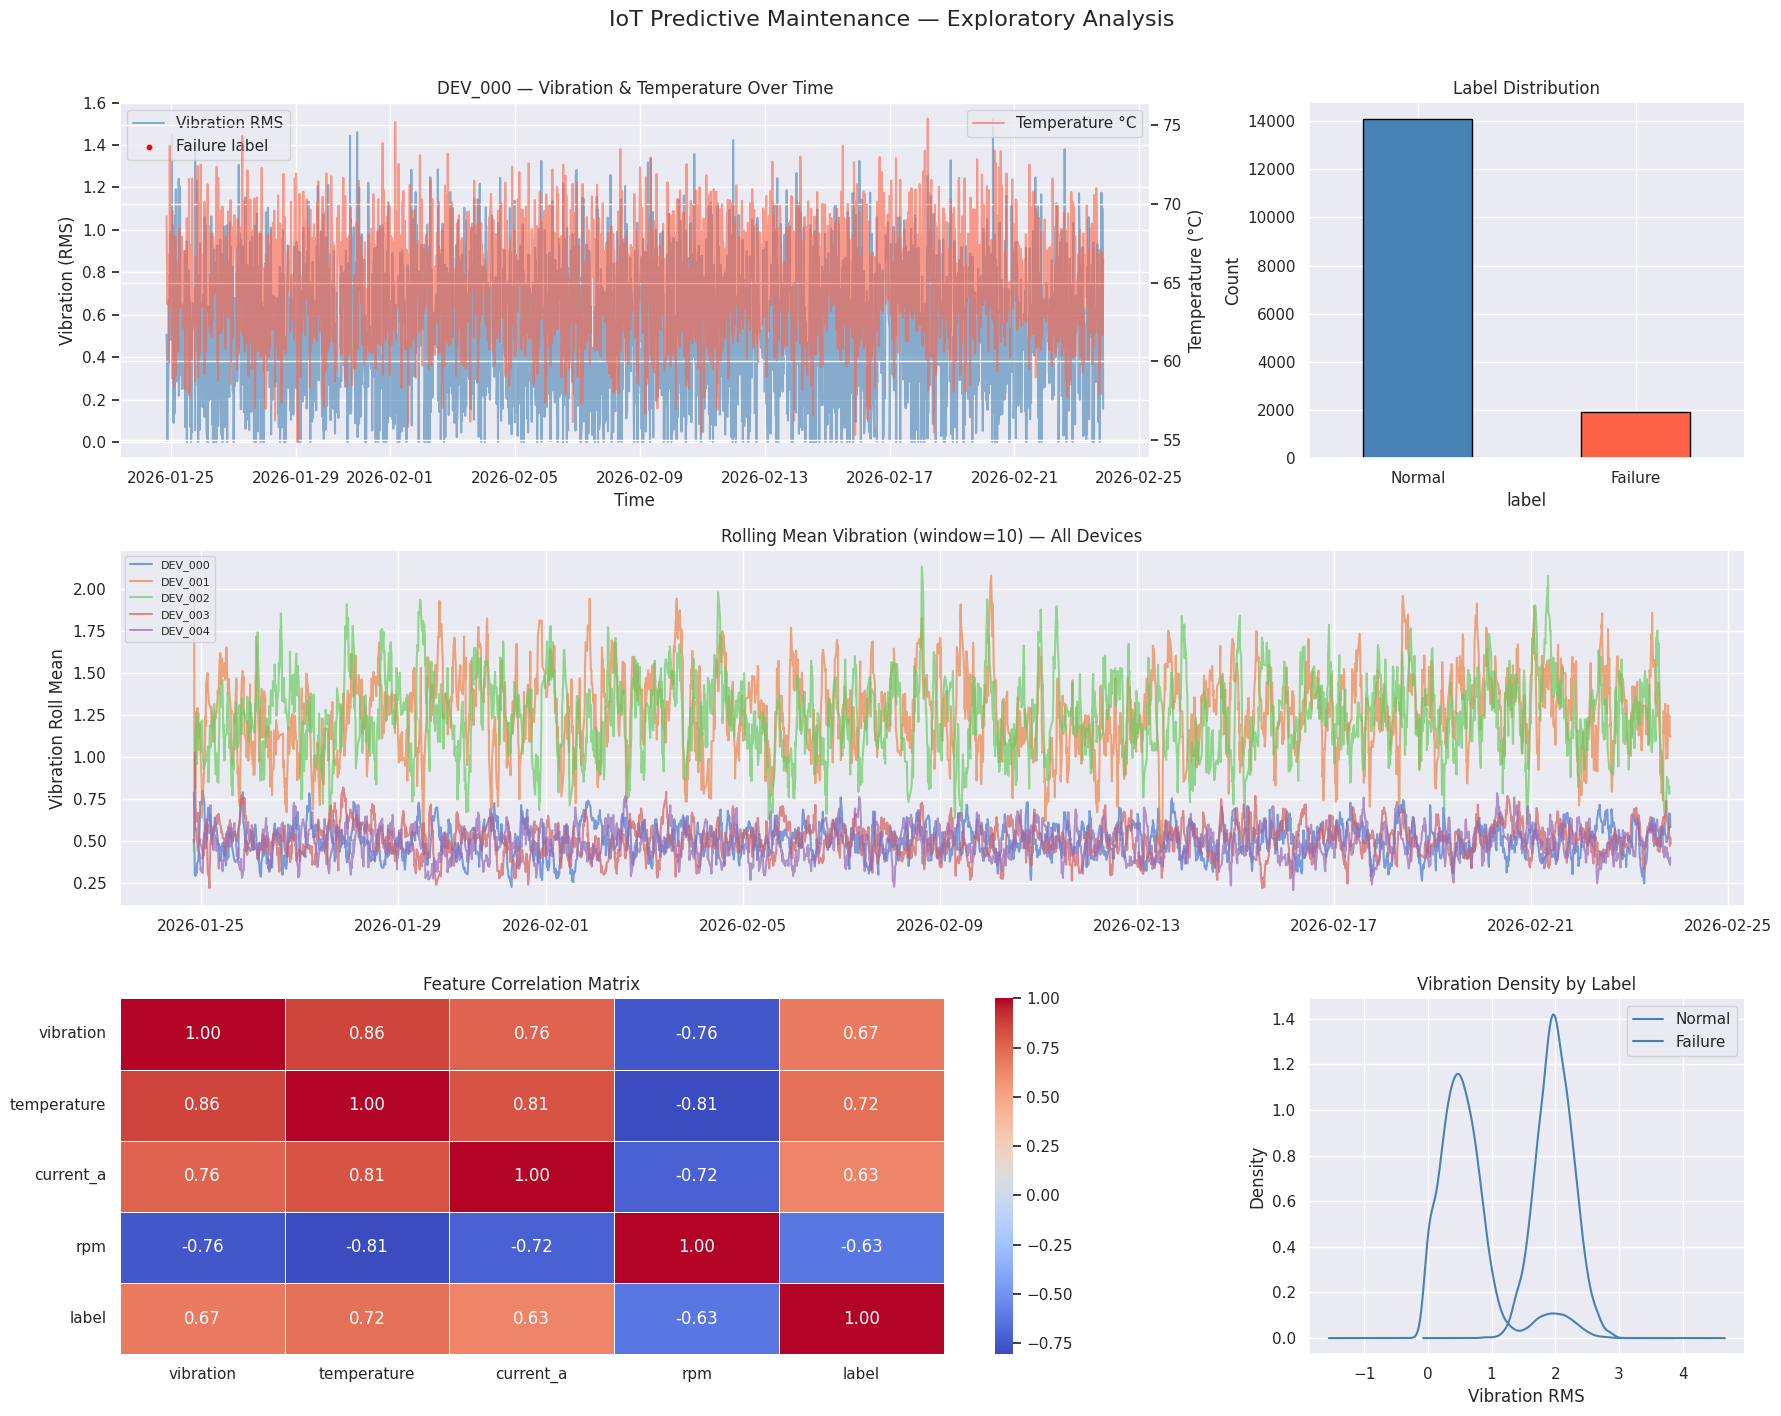

✅ EDA visualisations saved.


In [6]:
# ============================================================
# SECTION 4: TIME-SERIES ANALYSIS & EDA
# ============================================================

# ── CELL 6: Visualisations ───────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("IoT Predictive Maintenance — Exploratory Analysis", fontsize=16, y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig)

# 1. Sensor readings over time for one device
ax1 = fig.add_subplot(gs[0, :2])
dev = df_feat[df_feat["device_id"] == "DEV_000"].copy()
ax1.plot(dev["ts"], dev["vibration"], alpha=0.6, label="Vibration RMS", color="steelblue")
ax1_t = ax1.twinx()
ax1_t.plot(dev["ts"], dev["temperature"], alpha=0.6, label="Temperature °C", color="tomato")
failure_points = dev[dev["label"] == 1]
ax1.scatter(failure_points["ts"], failure_points["vibration"],
            color="red", zorder=5, s=10, label="Failure label")
ax1.set_title("DEV_000 — Vibration & Temperature Over Time")
ax1.set_xlabel("Time"); ax1.set_ylabel("Vibration (RMS)")
ax1_t.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left"); ax1_t.legend(loc="upper right")

# 2. Label distribution
ax2 = fig.add_subplot(gs[0, 2])
df_feat["label"].value_counts().plot(kind="bar", ax=ax2, color=["steelblue","tomato"], edgecolor="black")
ax2.set_title("Label Distribution"); ax2.set_xticklabels(["Normal","Failure"], rotation=0)
ax2.set_ylabel("Count")

# 3. Rolling mean vibration — normal vs degrading
ax3 = fig.add_subplot(gs[1, :])
for dev_id, grp in df_feat.groupby("device_id"):
    ax3.plot(grp["ts"], grp["vibration_roll_mean_10"],
             alpha=0.7, label=dev_id)
ax3.set_title("Rolling Mean Vibration (window=10) — All Devices")
ax3.set_ylabel("Vibration Roll Mean"); ax3.legend(fontsize=8)

# 4. Correlation heatmap (top raw features)
ax4 = fig.add_subplot(gs[2, :2])
raw_cols = ["vibration","temperature","current_a","rpm","label"]
corr = df_feat[raw_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax4, linewidths=0.5)
ax4.set_title("Feature Correlation Matrix")

# 5. Vibration distribution by label
ax5 = fig.add_subplot(gs[2, 2])
df_feat.groupby("label")["vibration"].plot(kind="density", ax=ax5,
    legend=True, color=["steelblue","tomato"])
ax5.set_title("Vibration Density by Label")
ax5.set_xlabel("Vibration RMS")
ax5.legend(["Normal","Failure"])

plt.tight_layout()
plt.savefig("/tmp/eda_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualisations saved.")

Train: (12800, 73) | Test: (3200, 73)
Positive rate (train): 12.05%

🌲 Random Forest — AUC-ROC: 0.9586
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      2815
     Failure       0.62      1.00      0.77       385

    accuracy                           0.93      3200
   macro avg       0.81      0.96      0.86      3200
weighted avg       0.95      0.93      0.93      3200


⚡ XGBoost — AUC-ROC: 0.9561
              precision    recall  f1-score   support

      Normal       0.99      0.92      0.96      2815
     Failure       0.62      0.96      0.75       385

    accuracy                           0.92      3200
   macro avg       0.81      0.94      0.85      3200
weighted avg       0.95      0.92      0.93      3200



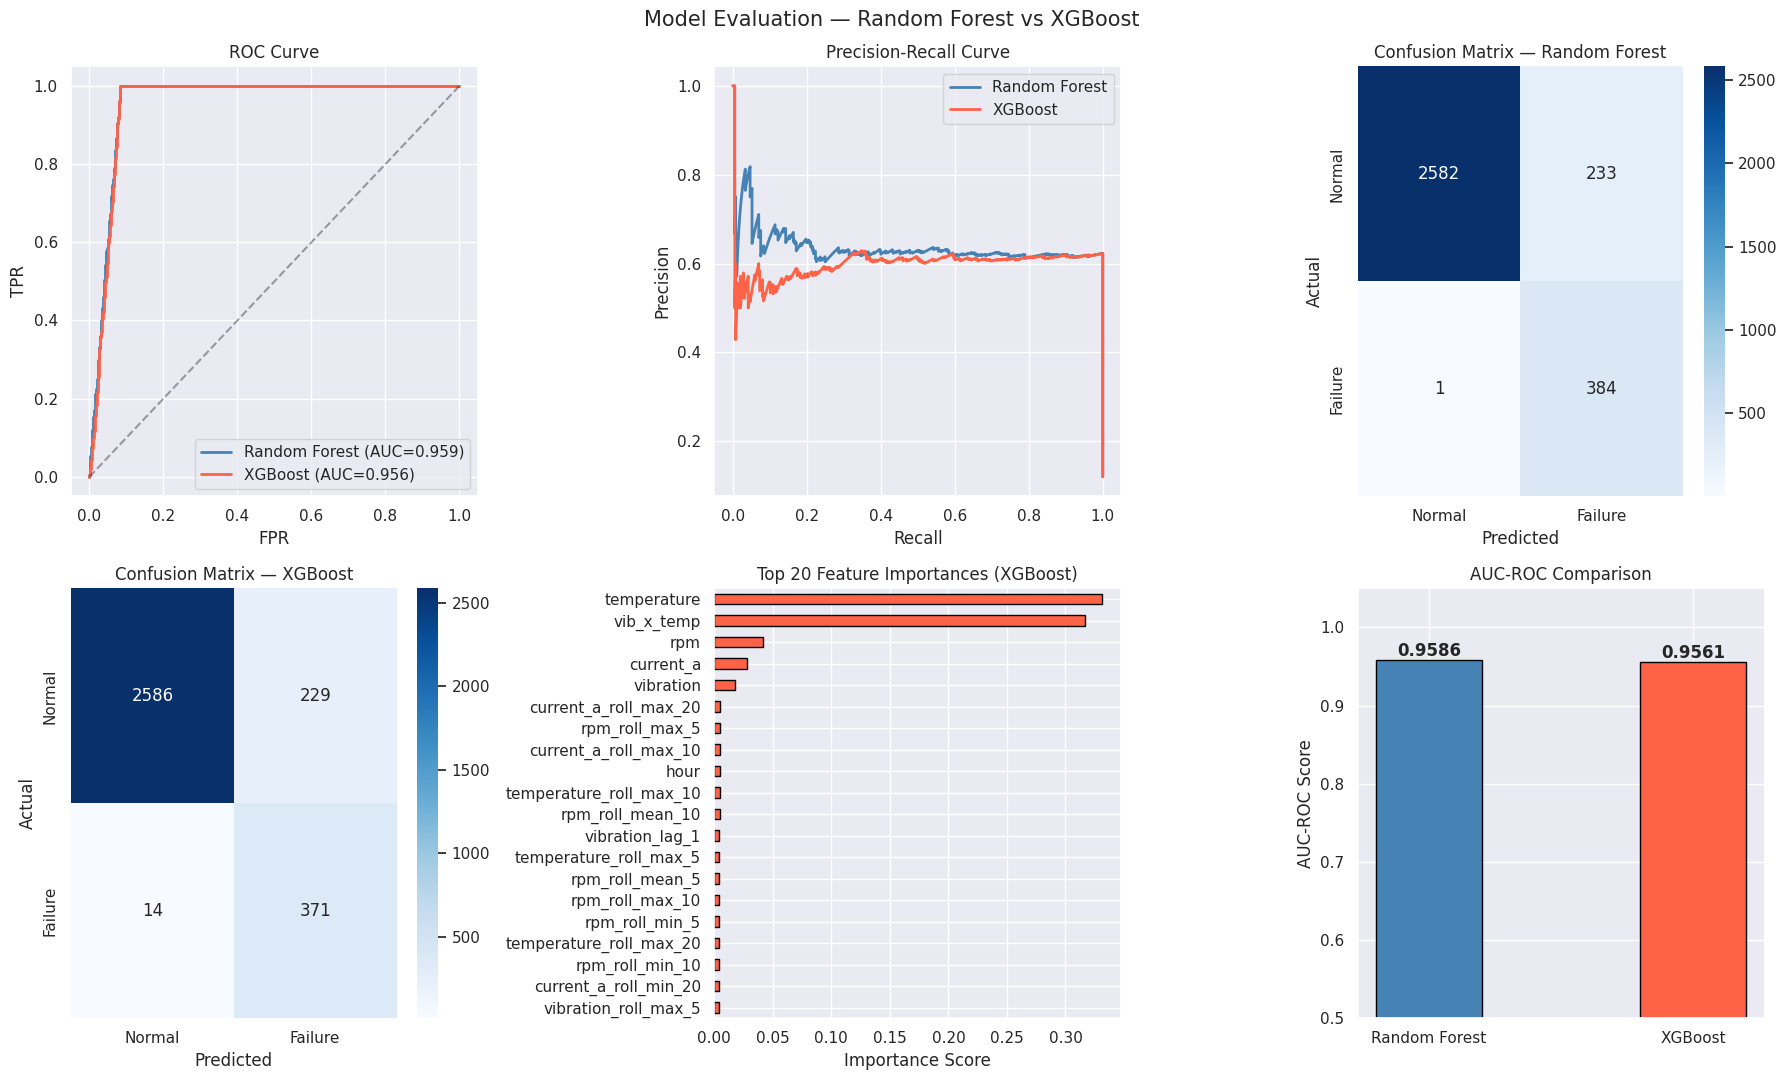

✅ Model evaluation plots saved.


In [7]:



# ============================================================
# SECTION 5: MODEL TRAINING — Random Forest vs XGBoost
# ============================================================

# ── CELL 7: Prepare data ────────────────────────────────────
X = df_feat[feature_cols].fillna(0)
y = df_feat["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Positive rate (train): {y_train.mean():.2%}")


# ── CELL 8: Random Forest ────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",   # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

rf_proba = rf.predict_proba(X_test_sc)[:, 1]
rf_pred  = rf.predict(X_test_sc)
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f"\n🌲 Random Forest — AUC-ROC: {rf_auc:.4f}")
print(classification_report(y_test, rf_pred, target_names=["Normal","Failure"]))


# ── CELL 9: XGBoost ─────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,   # handles imbalance
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_sc, y_train,
              eval_set=[(X_test_sc, y_test)],
              verbose=False)

xgb_proba = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_pred  = xgb_model.predict(X_test_sc)
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f"\n⚡ XGBoost — AUC-ROC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred, target_names=["Normal","Failure"]))


# ── CELL 10: Model comparison visualisations ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Model Evaluation — Random Forest vs XGBoost", fontsize=15)

# ROC curves
ax = axes[0, 0]
for name, proba, color in [("Random Forest", rf_proba, "steelblue"),
                             ("XGBoost",       xgb_proba, "tomato")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend()

# Precision-Recall curves
ax = axes[0, 1]
for name, proba, color in [("Random Forest", rf_proba, "steelblue"),
                             ("XGBoost",       xgb_proba, "tomato")]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ax.plot(r, p, label=name, color=color, lw=2)
ax.set_title("Precision-Recall Curve")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()

# Confusion matrices
for i, (name, pred) in enumerate([("Random Forest", rf_pred),
                                    ("XGBoost", xgb_pred)]):
    ax = axes[0, 2] if i == 0 else axes[1, 0]
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Failure"],
                yticklabels=["Normal","Failure"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

# Feature importance (XGBoost top 20)
ax = axes[1, 1]
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20)
top20.sort_values().plot(kind="barh", ax=ax, color="tomato", edgecolor="black")
ax.set_title("Top 20 Feature Importances (XGBoost)")
ax.set_xlabel("Importance Score")

# AUC comparison bar
ax = axes[1, 2]
models = ["Random Forest", "XGBoost"]
aucs   = [rf_auc, xgb_auc]
bars = ax.bar(models, aucs, color=["steelblue","tomato"], edgecolor="black", width=0.4)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{auc:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0.5, 1.05)
ax.set_title("AUC-ROC Comparison"); ax.set_ylabel("AUC-ROC Score")

plt.tight_layout()
plt.savefig("/tmp/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Model evaluation plots saved.")

In [8]:
# ============================================================
# SECTION 6: REAL-TIME MONITORING SIMULATION
# Mimics how the pipeline would score new Kafka events live
# ============================================================

# ── CELL 11: Live scoring stream ────────────────────────────
print("\n🔴 LIVE MONITORING — Simulating real-time inference stream")
print("=" * 60)

# Use XGBoost (best model) for live scoring
best_model = xgb_model if xgb_auc >= rf_auc else rf

alert_log = []
THRESHOLD = 0.6   # failure probability threshold for alert

for i in range(20):
    # Simulate one new Kafka message arriving
    is_fail = random.random() < 0.3
    raw = {
        "vibration":   round(np.random.normal(2.0 if is_fail else 0.5, 0.3), 4),
        "temperature": round(np.random.normal(90  if is_fail else 65,  3.0), 2),
        "current_a":   round(np.random.normal(6.5 if is_fail else 4.5, 0.5), 4),
        "rpm":         round(np.random.normal(1300 if is_fail else 1500, 50), 1),
    }

    # Build feature vector (simplified — in prod, computed from rolling window)
    row = {f: 0.0 for f in feature_cols}
    row.update(raw)
    # Fill interaction features
    row["vib_x_temp"] = raw["vibration"] * raw["temperature"]
    row["curr_x_rpm"] = raw["current_a"] * raw["rpm"]

    X_live = pd.DataFrame([row])[feature_cols].fillna(0)
    X_live_sc = scaler.transform(X_live)
    prob = best_model.predict_proba(X_live_sc)[0][1]

    status = "🚨 ALERT  " if prob >= THRESHOLD else "✅ Normal "
    if prob >= THRESHOLD:
        alert_log.append({"event": i+1, "prob": prob, **raw})

    print(f"Event {i+1:02d} | vib={raw['vibration']:.3f} "
          f"temp={raw['temperature']:.1f}°C "
          f"curr={raw['current_a']:.3f}A "
          f"rpm={raw['rpm']:.0f} | "
          f"Failure Prob: {prob:.3f} | {status}")
    time.sleep(0.05)   # simulates stream latency

print(f"\n🔔 {len(alert_log)} failure alerts triggered out of 20 events.")


# ── CELL 12: Alert summary + save run metadata ──────────────
if alert_log:
    alerts_df = pd.DataFrame(alert_log)
    print("\nAlert Log:")
    print(alerts_df.to_string(index=False))

# Log pipeline run to DB (like a Postgres audit table)
with get_conn() as conn:
    conn.execute("""
        INSERT INTO pipeline_runs (run_at, n_records, model_used, auc_roc)
        VALUES (?, ?, ?, ?)
    """, (datetime.now().isoformat(), len(df_feat),
          "XGBoost" if xgb_auc >= rf_auc else "RandomForest",
          max(xgb_auc, rf_auc)))

    runs = pd.read_sql("SELECT * FROM pipeline_runs", conn)
    print("\n📋 Pipeline Run History:")
    print(runs)


🔴 LIVE MONITORING — Simulating real-time inference stream
Event 01 | vib=2.094 temp=84.7°C curr=8.175A rpm=1309 | Failure Prob: 0.249 | ✅ Normal 
Event 02 | vib=2.400 temp=96.7°C curr=6.213A rpm=1247 | Failure Prob: 0.236 | ✅ Normal 
Event 03 | vib=-0.324 temp=68.7°C curr=5.544A rpm=1501 | Failure Prob: 0.044 | ✅ Normal 
Event 04 | vib=0.780 temp=56.8°C curr=4.862A rpm=1472 | Failure Prob: 0.055 | ✅ Normal 
Event 05 | vib=0.233 temp=63.0°C curr=5.283A rpm=1445 | Failure Prob: 0.051 | ✅ Normal 
Event 06 | vib=1.938 temp=88.8°C curr=6.503A rpm=1252 | Failure Prob: 0.249 | ✅ Normal 
Event 07 | vib=1.011 temp=64.2°C curr=4.109A rpm=1499 | Failure Prob: 0.052 | ✅ Normal 
Event 08 | vib=2.051 temp=82.4°C curr=6.522A rpm=1262 | Failure Prob: 0.243 | ✅ Normal 
Event 09 | vib=0.413 temp=59.5°C curr=4.949A rpm=1494 | Failure Prob: 0.051 | ✅ Normal 
Event 10 | vib=0.650 temp=61.6°C curr=4.283A rpm=1616 | Failure Prob: 0.048 | ✅ Normal 
Event 11 | vib=1.040 temp=66.5°C curr=5.049A rpm=1510 | Fail

In [9]:
# ============================================================
# SECTION 7: FINAL SUMMARY
# ============================================================

# ── CELL 13: Summary ────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║         PREDICTIVE MAINTENANCE PIPELINE — SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Kafka simulation     : 8,000 messages produced/consumed  ║
║  ✅ Database storage     : SQLite (PostgreSQL schema)        ║
║  ✅ Feature engineering  : Rolling stats, lags, interactions ║
║  ✅ Time-series analysis : Trends, anomalies, drift          ║""")
print(f"║  ✅ Random Forest AUC   : {rf_auc:.4f}                          ║")
print(f"║  ✅ XGBoost AUC         : {xgb_auc:.4f}                          ║")
print("""║  ✅ Live monitoring     : Real-time failure alert stream     ║
╠══════════════════════════════════════════════════════════════╣
║  KEY INTERVIEW TALKING POINTS                                ║
║  • Kafka producer/consumer message contract                  ║
║  • Rolling window feature engineering for time-series        ║
║  • class_weight / scale_pos_weight for imbalanced data       ║
║  • AUC-ROC + Precision-Recall for imbalanced evaluation      ║
║  • Threshold tuning for business cost (false negatives cost) ║
║  • Pipeline audit logging for reproducibility                ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         PREDICTIVE MAINTENANCE PIPELINE — SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Kafka simulation     : 8,000 messages produced/consumed  ║
║  ✅ Database storage     : SQLite (PostgreSQL schema)        ║
║  ✅ Feature engineering  : Rolling stats, lags, interactions ║
║  ✅ Time-series analysis : Trends, anomalies, drift          ║
║  ✅ Random Forest AUC   : 0.9586                          ║
║  ✅ XGBoost AUC         : 0.9561                          ║
║  ✅ Live monitoring     : Real-time failure alert stream     ║
╠══════════════════════════════════════════════════════════════╣
║  KEY INTERVIEW TALKING POINTS                                ║
║  • Kafka producer/consumer message contract                  ║
║  • Rolling window feature engineering for time-series        ║
║  • class_weight / scale_pos_weight for imbalanced data       ║
║  • AUC-ROC + Precision-Recall for im